In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')
print("Setup selesai.")

Setup selesai.


In [3]:
# Ganti path sesuai lokasi file pada komputer/sesi Anda
df = pd.read_csv('retail_sales.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536532,10009,PARTY BUNTING,1,11/24/2019 18:00,2.36,NaN,Portugal
1,537816,10016,VINTAGE SNAKES AND LADDERS,2,11/05/2019 01:00,11.33,16962.0,France
2,537592,10003,GLASS JAR CANDLE,1742,01/15/2020 07:00,1.42,15088.0,United Kingdom
3,537187,10002,RED WOOLLY HOTTIE MUG,2,01/21/2020 23:00,0.65,14753.0,United Kingdom
4,537176,10016,VINTAGE SNAKES AND LADDERS,3,02/01/2020 17:00,3.16,18073.0,United Kingdom


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   InvoiceNo    5000 non-null   int64  
 1   StockCode    5000 non-null   int64  
 2   Description  4990 non-null   str    
 3   Quantity     5000 non-null   int64  
 4   InvoiceDate  5000 non-null   str    
 5   UnitPrice    5000 non-null   float64
 6   CustomerID   4000 non-null   float64
 7   Country      5000 non-null   str    
dtypes: float64(2), int64(3), str(3)
memory usage: 561.3 KB


In [5]:
df.describe()

,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
count,5000.000000,5000.000000,5000.000000,5000.000000,4000.000000
mean,537299.460200,10009.452000,13.505800,14.016208,15328.337750
std,542.682959,5.810477,166.531689,256.454842,1731.450489
min,536365.000000,10000.000000,1.000000,0.250000,12346.000000
25%,536827.750000,10004.000000,2.000000,1.250000,13827.000000
50%,537291.000000,10009.000000,4.000000,2.410000,15364.000000
75%,537774.000000,10014.000000,8.000000,4.810000,16812.000000
max,538239.000000,10019.000000,7721.000000,7963.050000,18286.000000


In [6]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_pct})
missing_df[missing_df['Missing'] > 0]

,Missing,Percent
Description,10,0.2
CustomerID,1000,20.0


In [7]:
# Drop baris yang CustomerID-nya kosong
df_clean = df.dropna(subset=['CustomerID']).copy()
# Isi missing pada Description dengan 'Unknown'
df_clean['Description'] = df_clean['Description'].fillna('Unknown')
# Verifikasi ulang
df_clean.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

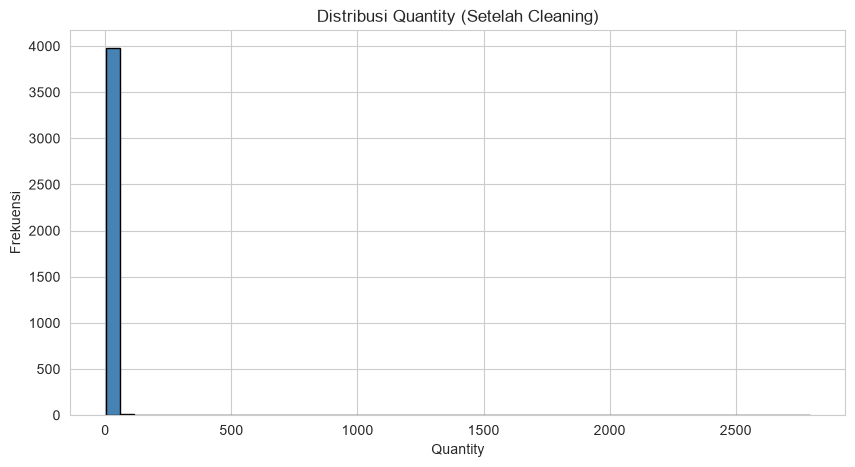

In [8]:
plt.figure(figsize=(10, 5))
df_clean['Quantity'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Distribusi Quantity (Setelah Cleaning)')
plt.xlabel('Quantity')
plt.ylabel('Frekuensi')
plt.show()

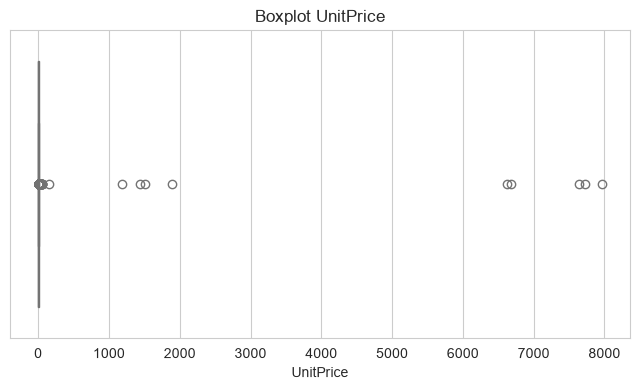

In [9]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean['UnitPrice'], color='lightgreen')
plt.title('Boxplot UnitPrice')
plt.show()

Shape sebelum filtering: (4000, 8)
Shape sesudah filtering: (3664, 8)


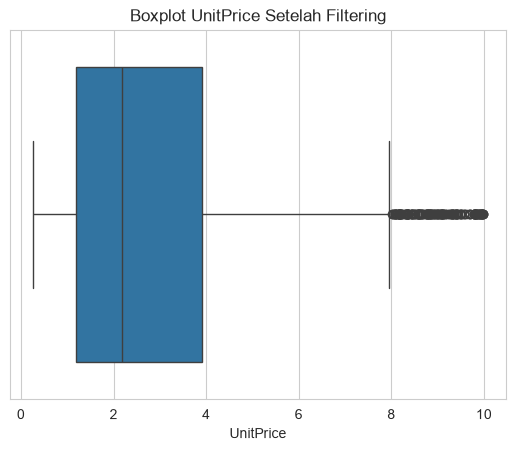

In [10]:
Q1 = df_clean['UnitPrice'].quantile(0.25)
Q3 = df_clean['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
low = Q1 - 1.5 * IQR
high = Q3 + 1.5 * IQR
df_filtered = df_clean[(df_clean['UnitPrice'] >= low) &
(df_clean['UnitPrice'] <= high)]
print("Shape sebelum filtering:", df_clean.shape)
print("Shape sesudah filtering:", df_filtered.shape)
sns.boxplot(x=df_filtered['UnitPrice'])
plt.title('Boxplot UnitPrice Setelah Filtering')
plt.show()

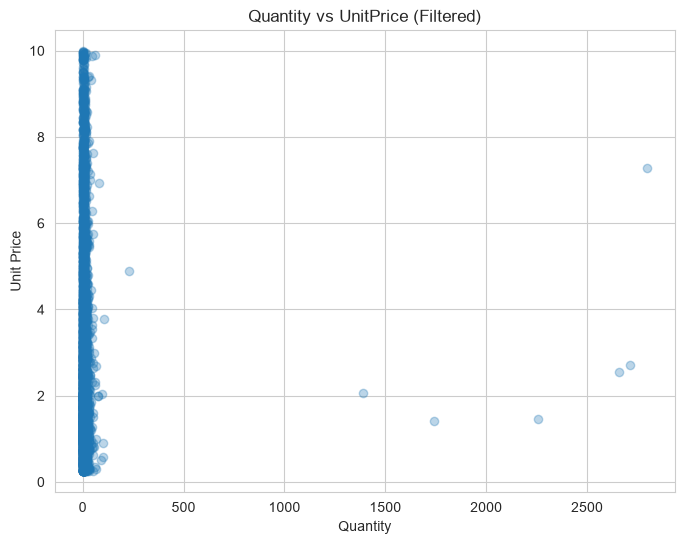

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(df_filtered['Quantity'], df_filtered['UnitPrice'], alpha=0.3)
plt.xlabel('Quantity')
plt.ylabel('Unit Price')
plt.title('Quantity vs UnitPrice (Filtered)')
plt.show()

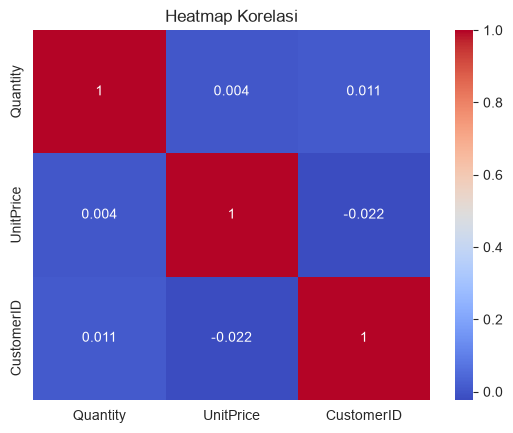

In [12]:
num_cols = ['Quantity', 'UnitPrice', 'CustomerID']
corr = df_filtered[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Heatmap Korelasi')
plt.show()

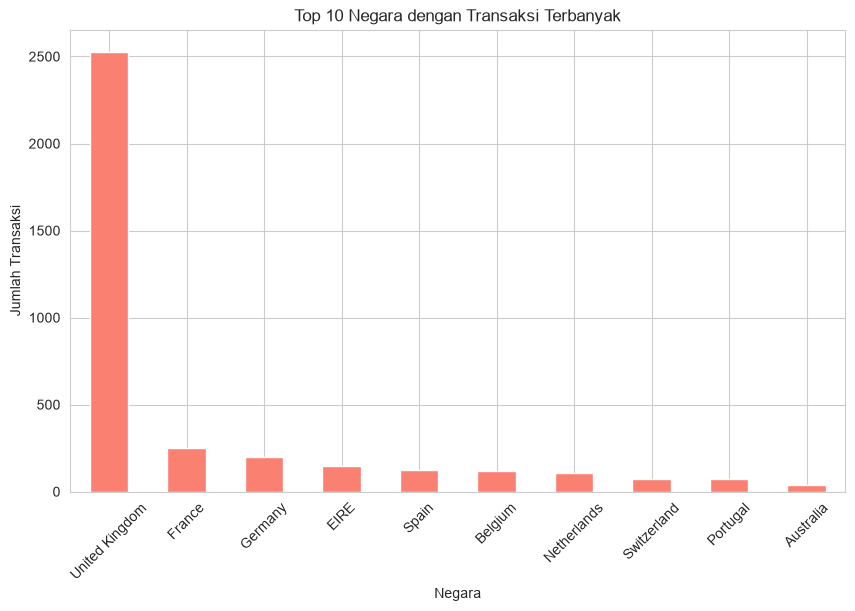

In [13]:
top_countries = df_filtered['Country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
top_countries.plot(kind='bar', color='salmon')
plt.title('Top 10 Negara dengan Transaksi Terbanyak')
plt.xlabel('Negara')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.show()